In [ ]:
from google.colab import files
uploaded = files.upload()

Saving archive (2).zip to archive (2).zip


In [ ]:
!ls

'archive (2).zip'   sample_data


In [ ]:
!unzip "archive (2).zip"

Archive:  archive (2).zip
  inflating: fer2013.csv             


In [ ]:
!ls dataset

ls: cannot access 'dataset': No such file or directory


In [ ]:
!ls

'archive (2).zip'   fer2013.csv   sample_data


In [ ]:
import pandas as pd

df = pd.read_csv("fer2013.csv")
print(df.head())
print(df.columns)

   emotion                                             pixels     Usage
0        0  70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...  Training
1        0  151 150 147 155 148 133 111 140 170 174 182 15...  Training
2        2  231 212 156 164 174 138 161 173 182 200 106 38...  Training
3        4  24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...  Training
4        6  4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...  Training
Index(['emotion', 'pixels', 'Usage'], dtype='object')


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

In [ ]:
df = pd.read_csv("fer2013.csv")
print(df.shape)
df.head()

(35887, 3)


,emotion,pixels,Usage
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,Training
1,0,151 150 147 155 148 133 111 140 170 174 182 15...,Training
2,2,231 212 156 164 174 138 161 173 182 200 106 38...,Training
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...,Training
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...,Training


In [ ]:
X = []
for pixel_sequence in df['pixels']:
    pixels = np.array(pixel_sequence.split(), dtype='float32')
    pixels = pixels.reshape(48, 48)
    X.append(pixels)

X = np.array(X)

# Normalize
X = X / 255.0

# CNN ke liye channel add karo
X = X.reshape(-1, 48, 48, 1)

print(X.shape)

(35887, 48, 48, 1)


In [ ]:
y = to_categorical(df['emotion'], num_classes=7)

print(y.shape)

(35887, 7)


In [ ]:
X_train = X[df['Usage'] == 'Training']
y_train = y[df['Usage'] == 'Training']

X_test = X[df['Usage'] != 'Training']
y_test = y[df['Usage'] != 'Training']

print(X_train.shape)
print(X_test.shape)

(28709, 48, 48, 1)
(7178, 48, 48, 1)


In [ ]:
model = Sequential([

    Conv2D(32, (3,3), activation='relu',
           input_shape=(48,48,1)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(7, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 619,015 (2.36 MB)

 Trainable params: 619,015 (2.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=64
)

Epoch 1/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 108s 232ms/step - accuracy: 0.3144 - loss: 1.7080 - val_accuracy: 0.4071 - val_loss: 1.5211
Epoch 2/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 145s 241ms/step - accuracy: 0.4353 - loss: 1.4724 - val_accuracy: 0.4805 - val_loss: 1.3629
Epoch 3/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 108s 242ms/step - accuracy: 0.4901 - loss: 1.3455 - val_accuracy: 0.5132 - val_loss: 1.2774
Epoch 4/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 137s 231ms/step - accuracy: 0.5205 - loss: 1.2647 - val_accuracy: 0.5330 - val_loss: 1.2209
Epoch 5/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 116s 258ms/step - accuracy: 0.5447 - loss: 1.2030 - val_accuracy: 0.5407 - val_loss: 1.2050
Epoch 6/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 131s 235ms/step - accuracy: 0.5641 - loss: 1.1535 - val_accuracy: 0.5499 - val_loss: 1.1890
Epoch 7/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 143s 236ms/step - accuracy: 0.5816 - loss: 1.1049 - val_accuracy: 0.5553 - val_loss: 1.1538
Epoch 8/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 111s 247ms/step - accuracy: 0.5976 -

In [ ]:
loss, acc = model.evaluate(X_test, y_test)

print("Accuracy =", acc*100)

225/225 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - accuracy: 0.5736 - loss: 1.4176
Accuracy = 57.35580921173096


In [ ]:
model.save("emotion_model.h5")

In [ ]:
from google.colab import files
files.download("emotion_model.h5")

In [10]:
from google.colab import files
uploaded = files.upload()

Saving emotion_model.h5 to emotion_model.h5


In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

In [12]:
from tensorflow.keras.models import load_model

model = load_model("emotion_model.h5")

print("Model Loaded Successfully")

Model Loaded Successfully


In [18]:
# Photo Upload
from google.colab import files
uploaded = files.upload()

Saving neutral.webp to neutral (3).webp


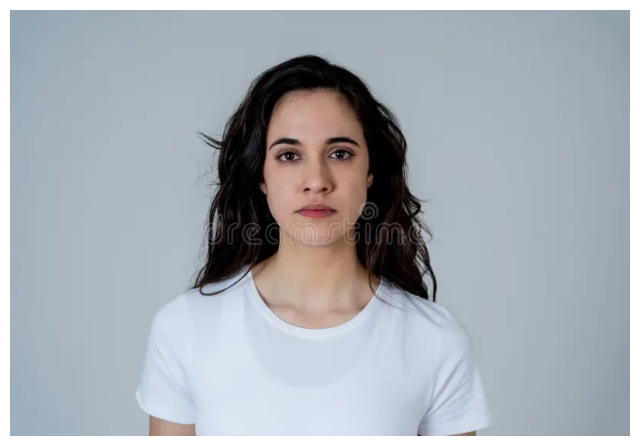

In [19]:
# Image Read
image_path = list(uploaded.keys())[0]

image = cv2.imread(image_path)

plt.figure(figsize=(8,8))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [20]:
# Face Detect
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades +
    "haarcascade_frontalface_default.xml"
)

faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=8,
    minSize=(100,100)
)

if len(faces) > 0:
    faces = sorted(
        faces,
        key=lambda x: x[2]*x[3],
        reverse=True
    )
    faces = [faces[0]]

print("Faces Found:", len(faces))



Faces Found: 1


In [21]:
# Emotion Predict
emotion_labels = [
    "Angry",
    "Disgust",
    "Fear",
    "Happy",
    "Sad",
    "Surprise",
    "Neutral"
]

output = image.copy()

for (x, y, w, h) in faces:

    face = gray[y:y+h, x:x+w]

    face = cv2.resize(face, (48,48))

    face = face.astype("float32") / 255.0

    face = np.expand_dims(face, axis=0)
    face = np.expand_dims(face, axis=-1)

    prediction = model.predict(face, verbose=0)

    emotion = emotion_labels[np.argmax(prediction)]

    print("Detected Emotion:", emotion)

    cv2.rectangle(output, (x,y), (x+w,y+h),
                  (0,255,0), 2)

    cv2.putText(output,
                emotion,
                (x,y-10),
                cv2.FONT_HERSHEY_SIMPLEX,
                1,
                (0,255,0),
                2)

Detected Emotion: Neutral


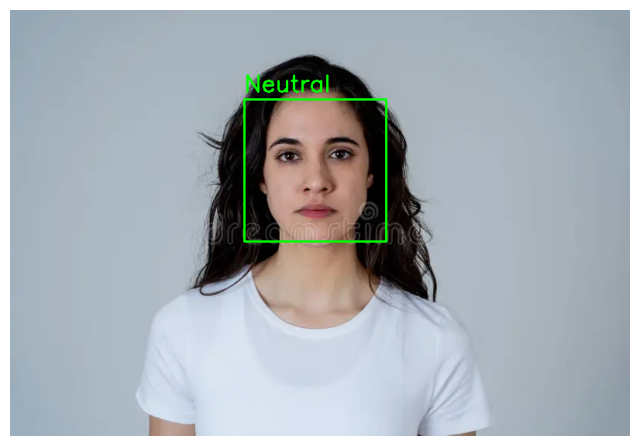

In [22]:
# Final Result
plt.figure(figsize=(8,8))
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()